In [197]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize, StandardScaler

In [198]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error,root_mean_squared_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
import warnings

In [199]:
df = pd.read_csv('StudentPerformanceFactors.csv')

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [200]:
print(df.describe())

       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.000000    70.000000      6.00000        63.000000   
50%        20.000000    80.000000      7.00000        75.000000   
75%        24.000000    90.000000      8.00000        88.000000   
max        44.000000   100.000000     10.00000       100.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6607.000000        6607.000000  6607.000000  
mean            1.493719           2.967610    67.235659  
std             1.230570           1.031231     3.890456  
min             0.000000           0.000000    55.000000  
25%             1.000000           2.000000    65.000000  
50%             1.000000           3.00000

In [201]:
print(df.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [202]:
print(df.describe())

       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.000000    70.000000      6.00000        63.000000   
50%        20.000000    80.000000      7.00000        75.000000   
75%        24.000000    90.000000      8.00000        88.000000   
max        44.000000   100.000000     10.00000       100.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6607.000000        6607.000000  6607.000000  
mean            1.493719           2.967610    67.235659  
std             1.230570           1.031231     3.890456  
min             0.000000           0.000000    55.000000  
25%             1.000000           2.000000    65.000000  
50%             1.000000           3.00000

In [203]:
print(df.dtypes)

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object


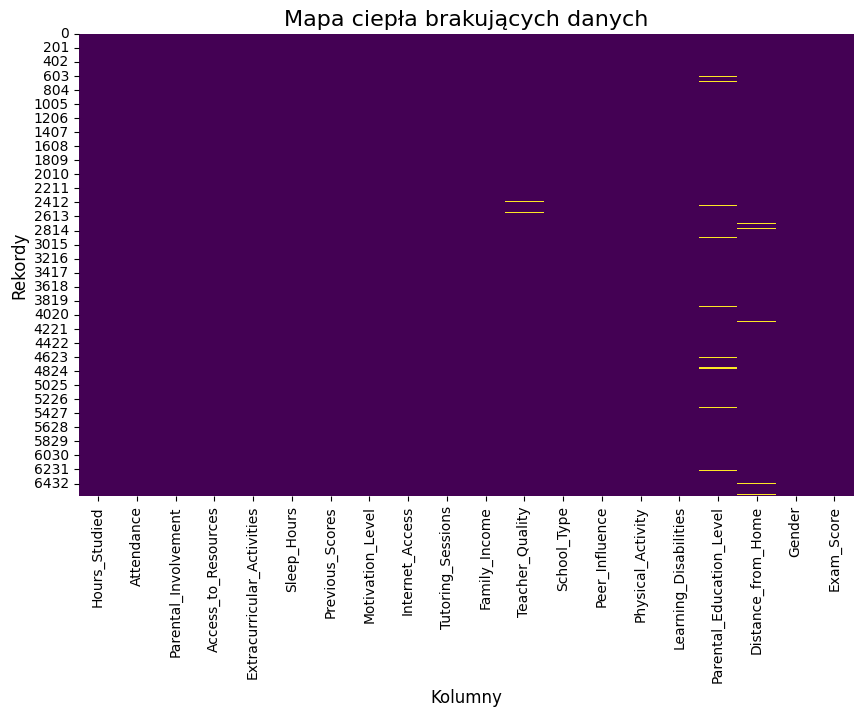

In [204]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Mapa ciepła brakujących danych', fontsize=16)
plt.xlabel('Kolumny', fontsize=12)
plt.ylabel('Rekordy', fontsize=12)

plt.show()

zrobic jakies wykresy potem

### 2.4. Przekształcenie danych kategorialnych: 

1. Usuniecie niepotrzebnych kolumn.

In [205]:
df.drop(['Physical_Activity', 'Peer_Influence', 'Parental_Education_Level', 'Family_Income'], axis=1, inplace=True)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Teacher_Quality,School_Type,Learning_Disabilities,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Medium,Public,No,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Public,No,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Public,No,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Public,No,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,High,Public,No,Near,Female,70


Dummying: płeć i odległość od domu, .

In [206]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

Zamiana na wartosci liczbowe oraz uzupelnienie brakujących medianą.

In [207]:
df['Distance_from_Home'] = df['Distance_from_Home'].map({'Near': 0, 'Moderate': 1, 'Far': 2})

median_distance = df['Distance_from_Home'].median()
print(median_distance)

# Wypełnienie brakujących wartości medianą
df['Distance_from_Home'].fillna(median_distance, inplace=True)

# Sprawdzenie wyników
print(df['Distance_from_Home'].isnull().sum())  # Powinno zwrócić 0
print(df['Distance_from_Home'].head(10))  # Podgląd przetworzonych danych

0.0
0
0    0.0
1    1.0
2    0.0
3    1.0
4    0.0
5    0.0
6    1.0
7    2.0
8    0.0
9    1.0
Name: Distance_from_Home, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_14128\1442269923.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Distance_from_Home'].fillna(median_distance, inplace=True)


In [208]:
df['Access_to_Resources'] = df['Access_to_Resources'].map({'Low': 0, 'Medium': 1, 'High': 2})

print(df['Access_to_Resources'].head(10))  # Podgląd przetworzonych dany

0    2
1    1
2    1
3    1
4    1
5    1
6    0
7    2
8    2
9    1
Name: Access_to_Resources, dtype: int64


In [209]:
df['Parental_Involvement'] = df['Parental_Involvement'].map({'Low': 0, 'Medium': 1, 'High': 2})

print(df['Parental_Involvement'].head(10))  # Podgląd przetworzonych dany

0    0
1    0
2    1
3    0
4    1
5    1
6    1
7    0
8    1
9    1
Name: Parental_Involvement, dtype: int64


In [210]:
df['Motivation_Level'] = df['Motivation_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

print(df['Motivation_Level'].head(10))  # Podgląd przetworzonych dany

0    0
1    0
2    1
3    1
4    1
5    1
6    0
7    1
8    2
9    1
Name: Motivation_Level, dtype: int64


In [211]:
df['Teacher_Quality'] = df['Teacher_Quality'].map({'Low': 0, 'Medium': 1, 'High': 2})

median_distance = df['Teacher_Quality'].median()
print(median_distance)

# Wypełnienie brakujących wartości medianą
df['Teacher_Quality'].fillna(median_distance, inplace=True)

# Sprawdzenie wyników
print(df['Teacher_Quality'].isnull().sum())  # Powinno zwrócić 0
print(df['Teacher_Quality'].head(10))  # Podgląd przetworzonych dany

1.0
0
0    1.0
1    1.0
2    1.0
3    1.0
4    2.0
5    1.0
6    1.0
7    2.0
8    0.0
9    2.0
Name: Teacher_Quality, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_14128\1809797257.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Teacher_Quality'].fillna(median_distance, inplace=True)


In [212]:
df = pd.get_dummies(df, columns=['Learning_Disabilities','Internet_Access', 'School_Type', 'Extracurricular_Activities'], drop_first=True)
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Teacher_Quality,Distance_from_Home,Gender,Exam_Score,Learning_Disabilities_Yes,Internet_Access_Yes,School_Type_Public,Extracurricular_Activities_Yes
0,23,84,0,2,7,73,0,0,1.0,0.0,0,67,False,True,True,False
1,19,64,0,1,8,59,0,2,1.0,1.0,1,61,False,True,True,False
2,24,98,1,1,7,91,1,2,1.0,0.0,0,74,False,True,True,True
3,29,89,0,1,8,98,1,1,1.0,1.0,0,71,False,True,True,True
4,19,92,1,1,6,65,1,3,2.0,0.0,1,70,False,True,True,True


In [213]:
# Przekształcenie kolumny 'Exam_Score' i previous score na 1 dla wartosci wiekszej lub rownej 70%
df['Exam_Score'] = (df['Exam_Score'] > 69).astype(int)

df['Previous_Scores'] = (df['Previous_Scores'] > 69).astype(int)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Teacher_Quality,Distance_from_Home,Gender,Exam_Score,Learning_Disabilities_Yes,Internet_Access_Yes,School_Type_Public,Extracurricular_Activities_Yes
0,23,84,0,2,7,1,0,0,1.0,0.0,0,0,False,True,True,False
1,19,64,0,1,8,0,0,2,1.0,1.0,1,0,False,True,True,False
2,24,98,1,1,7,1,1,2,1.0,0.0,0,1,False,True,True,True
3,29,89,0,1,8,1,1,1,1.0,1.0,0,1,False,True,True,True
4,19,92,1,1,6,0,1,3,2.0,0.0,1,1,False,True,True,True


In [214]:
y = df['Exam_Score']
X = df.drop(['Exam_Score'], axis = 1)

In [215]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state=42)

In [216]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [217]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")

Mean Absolute Error: 0.26222228005549697
Mean Squared Error: 0.09666743324405108
Root Mean Squared Error: 0.3109138678863506
R² Score: 0.4789677553541636


In [218]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

In [219]:
conf_matrix = confusion_matrix(y_test, y_pred)

class_report = classification_report(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)
print(f"Accuracy: {accuracy}")

Confusion Matrix:
 [[1455   40]
 [  83  405]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      1495
           1       0.91      0.83      0.87       488

    accuracy                           0.94      1983
   macro avg       0.93      0.90      0.91      1983
weighted avg       0.94      0.94      0.94      1983

Accuracy: 0.9379727685325264


krzywa ROC i krzywa czulosc/precyzja ?

In [220]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

In [221]:
conf_matrix = confusion_matrix(y_test, y_pred)

class_report = classification_report(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)

print("=== Wyniki Klasyfikacji KNN ===")
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)
print(f"Accuracy: {accuracy:.2f}")

=== Wyniki Klasyfikacji KNN ===
Confusion Matrix:
 [[1397   98]
 [ 123  365]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93      1495
           1       0.79      0.75      0.77       488

    accuracy                           0.89      1983
   macro avg       0.85      0.84      0.85      1983
weighted avg       0.89      0.89      0.89      1983

Accuracy: 0.89
